# 5.1. Introducción a MLflow y TensorBoard
## Dos herramientas para no perderse entre experimentos

Todo el foco está en **cómo registrar y mirar lo que pasa** cuando entrenamos modelos.


> **Dónde ejecutarlo:** en **Google Colab** (no necesitas GPU). También funciona en Jupyter en tu
> computador; donde haya diferencias, te lo indicamos.

### **1. El problema: "¿qué fue lo que hice aquella vez que funcionó?"**

Imagina que estás construyendo un modelo para predecir si un cliente va a **incumplir** el pago de un
crédito. Entrenar un modelo casi nunca sale bien a la primera: pruebas una configuración, miras el
resultado, cambias algo, vuelves a entrenar... Después de una tarde tienes algo así:

- Intento 1: 8 neuronas, velocidad de aprendizaje 0.01 → 81% de aciertos.
- Intento 2: 16 neuronas, velocidad 0.01 → 80%.
- Intento 3: 8 neuronas, velocidad 0.1 → 83%... ¿o fue con 16 neuronas?
- Intento 7: ... ya no te acuerdas.

Una semana después, tu jefe te pregunta: *"¿con qué configuración sacaste el 83%? ¿Puedes repetirlo?"*.
Si lo anotaste a mano en un Excel, con suerte lo tienes; si no, lo perdiste.

Hay además una segunda pregunta, más sutil: **¿cómo se comportó el modelo mientras aprendía?** Un modelo
que termina con 83% de aciertos puede haber llegado ahí de forma estable, o dando tumbos. Mirar solo el
número final no te lo dice.

Estas dos preguntas son justamente las que responden nuestras dos herramientas:

| Pregunta | Herramienta |
|---|---|
| ¿Cómo va aprendiendo mi modelo mientras se entrena? | **TensorBoard** |
| ¿Qué intentos he hecho, con qué configuración y qué resultado dio cada uno? | **MLflow** |

### Un mini glosario antes de seguir

| Término | Qué significa, en palabras simples |
|---|---|
| **Modelo** | Una fórmula que aprende de datos históricos para hacer predicciones (aquí: ¿este cliente va a incumplir?) |
| **Entrenar** | Mostrarle al modelo muchos ejemplos para que ajuste su fórmula |
| **Época** | Una pasada completa del modelo por todos los datos de entrenamiento. Entrenar 30 épocas = repasar los datos 30 veces |
| **Pérdida (*loss*)** | Qué tan equivocado está el modelo. **Mientras más baja, mejor.** Es lo que el modelo intenta reducir |
| **Exactitud (*accuracy*)** | Porcentaje de clientes clasificados correctamente. **Mientras más alta, mejor** |
| **Parámetro de configuración** (o *hiperparámetro*) | Una decisión que tomas tú antes de entrenar: cuántas neuronas, qué tan rápido aprende... |
| **Corrida (*run*)** | Un intento de entrenamiento con una configuración específica |
| **Experimento** | Un grupo de corridas que buscan resolver el mismo problema |

### 2. Las dos herramientas

### 2.1 TensorBoard: el tablero de instrumentos

Piensa en el **tablero de un carro**: mientras manejas, te muestra la velocidad, las revoluciones y la
temperatura del motor **en ese momento**. Si algo se sale de lo normal (el motor se recalienta), lo ves
de inmediato y puedes reaccionar.

TensorBoard hace eso con el entrenamiento de un modelo: dibuja, **época por época**, cómo evoluciona la
pérdida y la exactitud. Con esas curvas puedes ver si el modelo:

- está aprendiendo (la pérdida baja),
- aprende demasiado lento (la pérdida casi no se mueve),
- está "dando tumbos" (la pérdida sube y baja sin control), o
- está memorizando los datos en vez de aprender (le va cada vez mejor en entrenamiento y cada vez peor
  en datos que no ha visto; a esto se le llama **sobreajuste**).

Nació junto con **TensorFlow** (la librería de redes neuronales de Google), y se
usa sobre todo con redes neuronales, que son modelos que se entrenan por épocas.

### 2.2 MLflow: la bitácora del laboratorio

Un registro ordenado de cada procedimiento que se hizo, con qué parámetros, qué resultado dio y cuándo.

MLflow hace eso con tus modelos. Por cada corrida guarda:

- **Parámetros:** la configuración que usaste (8 neuronas, velocidad 0.01...).
- **Métricas:** los resultados (81% de exactitud...).
- **Archivos (*artefactos*):** gráficos, el modelo entrenado, lo que quieras conservar.
- **Datos automáticos:** fecha, duración, quién la ejecutó.

Después te deja ver todas las corridas en una tabla, ordenarlas por resultado y compararlas. Funciona
con **cualquier tipo de modelo**: una red neuronal, una regresión logística de scikit-learn, un árbol
de decisión etc...

### 2.3 Las diferencias, lado a lado

| | **TensorBoard** | **MLflow** |
|---|---|---|
| **Pregunta que responde** | ¿Cómo va aprendiendo este modelo? | ¿Cuál de todos mis intentos funcionó mejor, y cómo lo repito? |
| **Cuándo lo miras** | Durante (o justo después de) el entrenamiento | Cuando comparas intentos, días o semanas después |
| **Qué muestra** | Curvas época por época; detalles internos de la red | Tabla de corridas con parámetros, métricas finales y archivos |
| **Con qué modelos** | Pensado para redes neuronales (TensorFlow/Keras, también PyTorch) | Cualquier modelo de cualquier librería |
| **¿Sirve para una regresión logística?** | Poco: no se entrena por épocas, no hay curva que mirar | Sí, exactamente igual que para una red |
| **Dónde guarda la información** | Archivos en una carpeta (`logs/`) | Una base de datos (en este curso, un archivo SQLite `mlflow.db`) y una carpeta de archivos |
| **Qué haces tú en el código** | Agregas un *callback* al entrenamiento y él registra todo solo | Dices explícitamente qué anotar (`log_param`, `log_metric`...) |

**No compiten: se complementan.** En un proyecto real es común usar TensorBoard para vigilar una red
mientras aprende, y MLflow para llevar el registro de todos los intentos y guardar el modelo ganador.
En la sección 6 las usamos juntas.



### 3. Preparación

### 3.1 Instalación

Colab ya trae TensorFlow. Instalamos MLflow y TensorBoard con versiones fijas para que el cuaderno se
comporte igual para todos. Tarda un minuto.

In [18]:
# El signo "!" ejecuta un comando de la terminal desde el cuaderno.
# No reinstalamos TensorFlow: Colab ya lo trae configurado.
!pip install -q "mlflow==3.16.1" "tensorboard==2.21.0"

In [19]:
import os

# MLflow imprime un aviso dirigido a asistentes de IA que no nos interesa aquí
os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"
# Oculta mensajes técnicos de TensorFlow que pueden asustar pero no son errores
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import shutil
import subprocess
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import mlflow

keras.utils.set_random_seed(42)  # para que todos obtengamos resultados parecidos

print("TensorFlow:", tf.__version__, "| MLflow:", mlflow.__version__)

TensorFlow: 2.21.0 | MLflow: 3.16.1


### 3.2 Los datos: clientes de crédito (simulados)

Para no depender de descargas, **inventamos** 2 000 clientes con cuatro características y una columna
que dice si incumplieron o no. Los datos son simulados, pero siguen reglas razonables: más deuda y más
moras históricas aumentan el riesgo; más ingreso y más antigüedad laboral lo reducen.

In [20]:
rng = np.random.default_rng(42)
n_clientes = 2000

clientes = pd.DataFrame({
    "ingreso_millones": rng.lognormal(mean=1.0, sigma=0.5, size=n_clientes).round(2),
    "deuda_sobre_ingreso": rng.uniform(0, 0.8, n_clientes).round(3),
    "moras_historicas": rng.poisson(0.7, n_clientes),
    "antiguedad_anios": rng.integers(0, 20, n_clientes),
})

# Regla (oculta para el modelo) con la que simulamos quién incumple
riesgo = (-1.0 - 0.5 * clientes["ingreso_millones"] + 3.0 * clientes["deuda_sobre_ingreso"]
          + 0.9 * clientes["moras_historicas"] - 0.06 * clientes["antiguedad_anios"])
clientes["incumple"] = rng.binomial(1, 1 / (1 + np.exp(-riesgo)))

print(f"Porcentaje de clientes que incumplen: {clientes['incumple'].mean():.1%}")
clientes.head()

Porcentaje de clientes que incumplen: 27.9%


,ingreso_millones,deuda_sobre_ingreso,moras_historicas,antiguedad_anios,incumple
0,3.17,0.034,0,7,0
1,1.62,0.356,0,5,0
2,3.96,0.438,0,3,0
3,4.35,0.117,0,6,0
4,1.02,0.269,2,14,0


Separamos los datos en dos grupos, como haría un banco: el modelo **aprende** con el 80% de los
clientes y lo **evaluamos** con el 20% restante, que nunca vio. Además ponemos todas las columnas en
una escala parecida (a las redes neuronales no les gusta mezclar millones con proporciones entre 0 y 1).

In [21]:
X = clientes.drop(columns="incumple")
y = clientes["incumple"]

X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

escalador = StandardScaler().fit(X_entrena)
X_entrena = escalador.transform(X_entrena)
X_prueba = escalador.transform(X_prueba)

print(f"Clientes para entrenar: {len(X_entrena)} | para evaluar: {len(X_prueba)}")

Clientes para entrenar: 1600 | para evaluar: 400


### 3.3 El modelo: una red neuronal muy pequeña

No necesitas entender los detalles. Basta con saber que la función `crear_modelo` arma una red y que
tiene **dos perillas** que vamos a mover:

- `neuronas`: qué tan "grande" es la red.
- `tasa_aprendizaje`: qué tan grandes son los pasos que da al aprender. Muy pequeña → aprende lento;
  muy grande → se pasa de largo y da tumbos. Es como ajustar el volumen de un equipo de sonido: con
  giros diminutos tardas mucho en llegar al punto justo, y con giros bruscos te pasas una y otra vez.

In [22]:
def crear_modelo(neuronas, tasa_aprendizaje):
    modelo = keras.Sequential([
        layers.Input(shape=(4,)),                      # 4 características por cliente
        layers.Dense(neuronas, activation="relu"),
        layers.Dense(1, activation="sigmoid"),         # probabilidad de incumplir
    ])
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=tasa_aprendizaje),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return modelo


# Las tres configuraciones que vamos a comparar en todo el ejercicio
CONFIGURACIONES = {
    "lenta": 0.0003,
    "moderada": 0.01,
    "brusca": 0.5,
}
NEURONAS = 8
EPOCAS = 30

### 4. Ejercicio con TensorBoard: ver aprender a tres modelos

### 4.1 Registrar el entrenamiento

Para usar TensorBoard basta con **una línea**: crear un *callback* de TensorBoard y pasárselo al
entrenamiento. Un *callback* es como un asistente que Keras llama al final de cada época; este en
particular anota la pérdida y la exactitud en una carpeta.

Entrenamos los tres modelos, cada uno escribiendo en su propia subcarpeta para que TensorBoard pueda
distinguirlos. Con `validation_split=0.2`, Keras aparta el 20% de los datos de entrenamiento para
medir, en cada época, cómo le va al modelo con clientes que no está usando para aprender.

In [23]:
CARPETA_TENSORBOARD = "logs_tensorboard"
shutil.rmtree(CARPETA_TENSORBOARD, ignore_errors=True)  # empezamos limpio si repites la celda

for nombre, tasa in CONFIGURACIONES.items():
    registro_tb = keras.callbacks.TensorBoard(log_dir=f"{CARPETA_TENSORBOARD}/{nombre}")

    modelo = crear_modelo(NEURONAS, tasa)
    modelo.fit(
        X_entrena, y_entrena,
        epochs=EPOCAS,
        validation_split=0.2,
        callbacks=[registro_tb],   # ← esta es la única línea "de TensorBoard"
        verbose=0,
    )
    print(f"Modelo '{nombre}' (tasa {tasa}) entrenado.")

Modelo 'lenta' (tasa 0.0003) entrenado.
Modelo 'moderada' (tasa 0.01) entrenado.
Modelo 'brusca' (tasa 0.5) entrenado.


¿Qué quedó guardado? Solo unos archivos en la carpeta `logs_tensorboard`. TensorBoard no es más que
un programa que **lee esos archivos y los dibuja**.

In [24]:
for carpeta, _, archivos in sorted(os.walk(CARPETA_TENSORBOARD)):
    for archivo in archivos:
        print(os.path.join(carpeta, archivo))

logs_tensorboard/brusca/train/events.out.tfevents.1790635284.MacBook-Pro-de-Natalia.local.47393.12.v2
logs_tensorboard/brusca/validation/events.out.tfevents.1790635285.MacBook-Pro-de-Natalia.local.47393.13.v2
logs_tensorboard/lenta/train/events.out.tfevents.1790635280.MacBook-Pro-de-Natalia.local.47393.8.v2
logs_tensorboard/lenta/validation/events.out.tfevents.1790635280.MacBook-Pro-de-Natalia.local.47393.9.v2
logs_tensorboard/moderada/train/events.out.tfevents.1790635282.MacBook-Pro-de-Natalia.local.47393.10.v2
logs_tensorboard/moderada/validation/events.out.tfevents.1790635282.MacBook-Pro-de-Natalia.local.47393.11.v2


### 4.2 Abrir TensorBoard

Las dos celdas siguientes abren TensorBoard **dentro del cuaderno**. La primera vez puede tardar unos
segundos en aparecer.

> **Si usas VS Code** y no ves nada, abre una terminal en la carpeta del cuaderno, ejecuta
> `tensorboard --logdir logs_tensorboard` y entra a `http://localhost:6006` en tu navegador.

In [25]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [26]:
%tensorboard --logdir logs_tensorboard

Reusing TensorBoard on port 6006 (pid 47521), started 2:10:59 ago. (Use '!kill 47521' to kill it.)

### 4.3 Cómo leer TensorBoard

1. Ve a la pestaña **Scalars** (si no aparece arriba, búscala en el menú desplegable).
2. Abre la gráfica **`epoch_loss`**: es la pérdida en cada época. El eje horizontal son las épocas; el
   vertical, qué tan equivocado está el modelo.
3. A la izquierda verás las corridas: `lenta/train`, `lenta/validation`, `moderada/train`... Cada una
   tiene un color. Puedes activarlas y desactivarlas con las casillas.
   - `train` = cómo le va con los datos con los que aprende.
   - `validation` = cómo le va con los datos que tiene apartados. **Esta es la que más importa.**
4. Mueve el control **Smoothing** a 0 para ver las curvas sin suavizar.
5. Mira también **`epoch_accuracy`** (exactitud).

### 4.4 Preguntas para responder mirando TensorBoard

1. ¿Cuál de los tres modelos baja su pérdida más despacio? ¿Coincide con su nombre?
2. ¿Alguna curva se ve "nerviosa", subiendo y bajando de una época a otra? ¿Cuál y por qué crees que
   pasa?
3. Si tuvieras que detener el entrenamiento del modelo `lenta` en la época 30, ¿crees que ya terminó de
   aprender o le faltaba?
4. ¿Qué dirías de un modelo cuya curva de `train` siguiera bajando mientras la de `validation`
   empezara a subir?

<details>
<summary><b>Ver respuestas orientativas</b> (primero intenta responder tú)</summary>

1. `lenta`: su curva baja de forma suave pero muy despacio. Con pasos tan pequeños avanza poco en cada
   época.
2. `brusca`: en las primeras épocas su pérdida sube y baja a saltos, porque los pasos son tan grandes que
   el modelo "se pasa" del punto óptimo y rebota. Después suele quedarse estancada en una pérdida **peor**
   que la de `moderada`.
3. Su curva sigue bajando en la época 30, así que todavía le faltaba aprender: necesitaría más épocas.
4. Que está **sobreajustando**: memoriza los datos de entrenamiento en lugar de aprender patrones que
   sirvan para clientes nuevos. Es la señal clásica para detener el entrenamiento. Mira con atención la
   curva `moderada/validation`: es probable que llegue a su mínimo en las primeras épocas y después
   **suba levemente** mientras la de entrenamiento sigue bajando. Es una forma suave de sobreajuste.
</details>

Fíjate en lo que acabamos de hacer: TensorBoard nos mostró **cómo** aprendió cada modelo, pero no
guardó por ningún lado un resumen de "configuración → resultado final" que podamos consultar dentro de
un mes. Para eso está MLflow.

### 5. Ejercicio con MLflow: registrar y comparar intentos

### 5.1 Dónde se guarda el registro

Primero le decimos a MLflow **dónde** guardar la bitácora (un archivo de base de datos, `mlflow.db`,
en la carpeta del cuaderno) y **en qué experimento** anotar las corridas. Si el experimento no existe,
lo crea.

In [27]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("riesgo_credito_basico")

<Experiment: artifact_location='/Users/nataliaacevedo/MisCursos/docs/source/analitica_financiera/mlruns/1', creation_time=1790627429173, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790627429173, lifecycle_stage='active', name='riesgo_credito_basico', tags={}, trace_location=None, workspace='default'>

### 5.2 Registrar las corridas

La estructura es siempre la misma:

```python
with mlflow.start_run(run_name="nombre del intento"):   # abre una página nueva en la bitácora
    mlflow.log_param("nombre", valor)                    # anota una configuración
    ...entrenar...
    mlflow.log_metric("nombre", valor)                   # anota un resultado
    mlflow.log_figure(figura, "archivo.png")             # guarda un gráfico
```

Todo lo que ocurra dentro del bloque `with` queda asociado a esa corrida. Entrenamos de nuevo los tres
modelos (es rápido), pero ahora anotando en MLflow.

In [28]:
def curva_aprendizaje(historial, titulo):
    """Dibuja la pérdida por época, para guardarla como archivo en MLflow."""
    figura, ax = plt.subplots(figsize=(5, 3))
    ax.plot(historial.history["loss"], label="entrenamiento")
    ax.plot(historial.history["val_loss"], label="validación")
    ax.set_xlabel("Época")
    ax.set_ylabel("Pérdida")
    ax.set_title(titulo)
    ax.legend()
    plt.close(figura)  # no la mostramos aquí; la veremos en MLflow
    return figura


for nombre, tasa in CONFIGURACIONES.items():
    with mlflow.start_run(run_name=f"red_{nombre}"):
        # 1. Anotamos la configuración
        mlflow.log_param("tipo_modelo", "red neuronal")
        mlflow.log_param("tasa_aprendizaje", tasa)
        mlflow.log_param("neuronas", NEURONAS)
        mlflow.log_param("epocas", EPOCAS)

        # 2. Entrenamos (igual que antes, pero sin TensorBoard)
        modelo = crear_modelo(NEURONAS, tasa)
        historial = modelo.fit(X_entrena, y_entrena, epochs=EPOCAS, validation_split=0.2, verbose=0)

        # 3. Evaluamos con los clientes de prueba y anotamos los resultados
        perdida, exactitud = modelo.evaluate(X_prueba, y_prueba, verbose=0)
        mlflow.log_metric("exactitud_prueba", exactitud)
        mlflow.log_metric("perdida_prueba", perdida)

        # 4. Guardamos un gráfico como archivo de la corrida
        mlflow.log_figure(curva_aprendizaje(historial, f"red_{nombre}"), "curva_aprendizaje.png")

    print(f"Corrida 'red_{nombre}' registrada: exactitud en prueba = {exactitud:.1%}")

Corrida 'red_lenta' registrada: exactitud en prueba = 72.3%
Corrida 'red_moderada' registrada: exactitud en prueba = 76.5%
Corrida 'red_brusca' registrada: exactitud en prueba = 72.3%


### 5.3 Un modelo que TensorBoard no puede mostrar

Una **regresión logística** es un modelo clásico de riesgo de crédito. No se entrena por épocas, así
que en TensorBoard no habría ninguna curva que mirar. En MLflow, en cambio, se registra exactamente
igual que la red neuronal, y queda en la misma tabla para compararla.

In [29]:
with mlflow.start_run(run_name="regresion_logistica"):
    mlflow.log_param("tipo_modelo", "regresión logística")

    regresion = LogisticRegression().fit(X_entrena, y_entrena)
    exactitud = regresion.score(X_prueba, y_prueba)
    mlflow.log_metric("exactitud_prueba", exactitud)

print(f"Corrida 'regresion_logistica' registrada: exactitud en prueba = {exactitud:.1%}")

Corrida 'regresion_logistica' registrada: exactitud en prueba = 76.8%


### 5.4 Consultar la bitácora desde el código

Esto funciona en cualquier lugar (Colab, Jupyter, VS Code). `mlflow.search_runs` devuelve todas las
corridas del experimento como una tabla de pandas.

In [30]:
corridas = mlflow.search_runs(experiment_names=["riesgo_credito_basico"])

columnas = ["tags.mlflow.runName", "params.tipo_modelo", "params.tasa_aprendizaje",
            "metrics.exactitud_prueba", "start_time"]
tabla = corridas[columnas].rename(columns={
    "tags.mlflow.runName": "corrida",
    "params.tipo_modelo": "tipo",
    "params.tasa_aprendizaje": "tasa_aprendizaje",
    "metrics.exactitud_prueba": "exactitud_prueba",
    "start_time": "inicio",
}).sort_values("exactitud_prueba", ascending=False)

tabla

,corrida,tipo,tasa_aprendizaje,exactitud_prueba,inicio
0,regresion_logistica,regresión logística,NaN,0.7675,2026-09-28 22:41:33.478000+00:00
5,regresion_logistica,regresión logística,NaN,0.7675,2026-09-28 20:30:36.178000+00:00
2,red_moderada,red neuronal,0.01,0.7650,2026-09-28 22:41:29.106000+00:00
4,red_16_neuronas,red neuronal,0.01,0.7650,2026-09-28 20:30:51.650000+00:00
7,red_moderada,red neuronal,0.01,0.7575,2026-09-28 20:30:31.776000+00:00
1,red_brusca,red neuronal,0.5,0.7225,2026-09-28 22:41:31.336000+00:00
3,red_lenta,red neuronal,0.0003,0.7225,2026-09-28 22:41:26.920000+00:00
6,red_brusca,red neuronal,0.5,0.7225,2026-09-28 20:30:33.843000+00:00
8,red_lenta,red neuronal,0.0003,0.7225,2026-09-28 20:30:29.356000+00:00


En el gráfico agregamos una **línea de referencia**: la exactitud que obtendría un "modelo" que no
aprende nada y simplemente dice que **ningún** cliente va a incumplir. Como la mayoría de los clientes sí
paga, ese modelo perezoso ya acierta bastante. Cualquier modelo que valga la pena tiene que superarlo.

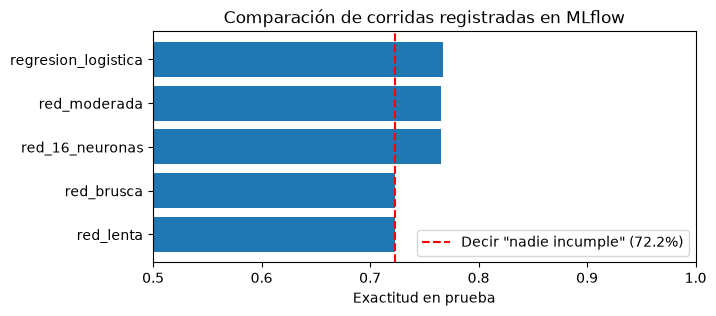

In [31]:
referencia = 1 - y_prueba.mean()  # exactitud de decir siempre "no incumple"

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(tabla["corrida"], tabla["exactitud_prueba"])
ax.axvline(referencia, color="red", linestyle="--", label=f'Decir "nadie incumple" ({referencia:.1%})')
ax.set_xlim(0.5, 1)
ax.set_xlabel("Exactitud en prueba")
ax.set_title("Comparación de corridas registradas en MLflow")
ax.legend(loc="lower right")
ax.invert_yaxis()
plt.show()

### 5.5 Abrir la interfaz de MLflow

MLflow también tiene una página web para explorar la bitácora con clics. Para verla hay que encender
un pequeño **servidor** (un programa que se queda corriendo y responde cuando el navegador le pide la
página).

La siguiente celda lo enciende y te da un enlace:

- **En Colab:** aparece un enlace; haz clic y se abre MLflow en otra pestaña.
- **En tu computador:** entra a `http://localhost:5000` en tu navegador.

> **Sobre las opciones `--allowed-hosts`, `--cors-allowed-origins` y `--x-frame-options`:** MLflow trae
> protecciones que solo aceptan visitas desde tu propio computador. Colab muestra la página a través de
> un intermediario de Google, y esas protecciones lo bloquearían. Aquí las desactivamos porque la
> máquina de Colab es temporal y solo la usas tú. **Nunca lo hagas en un servidor compartido o
> accesible desde internet.** En tu computador no necesitas esas opciones: basta con `mlflow ui`.

In [32]:
servidor_mlflow = subprocess.Popen(
    [sys.executable, "-m", "mlflow", "ui",
     "--backend-store-uri", "sqlite:///mlflow.db",
     "--port", "5000",
     "--allowed-hosts", "*", "--cors-allowed-origins", "*", "--x-frame-options", "NONE"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)
time.sleep(15)  # le damos tiempo a encender

try:
    from google.colab import output
    output.serve_kernel_port_as_window(5000)
except ImportError:
    print("No estás en Colab: abre http://localhost:5000 en tu navegador.")

No estás en Colab: abre http://localhost:5000 en tu navegador.


### 5.6 Cómo leer la interfaz de MLflow

1. En la lista de experimentos, entra a **`riesgo_credito_basico`**.
2. Verás una **tabla con las cuatro corridas**: una fila por intento, con sus parámetros y métricas.
   Haz clic en el encabezado `exactitud_prueba` para ordenarlas.
3. Marca las casillas de varias corridas y usa el botón **Compare** para verlas lado a lado.
4. Haz clic en el nombre de una corrida de red neuronal (por ejemplo `red_moderada`) y busca la
   sección de **artefactos (*Artifacts*)**: ahí está el gráfico `curva_aprendizaje.png` que guardamos.

Si el enlace no abre o la página sale en blanco, no te preocupes: la tabla y el gráfico de la
sección 5.4 muestran exactamente la misma información.

### 5.7 Preguntas para responder mirando MLflow

1. ¿Qué corrida obtuvo la mayor exactitud en prueba? ¿Con qué tasa de aprendizaje?
2. ¿Le fue mejor a la red neuronal o a la regresión logística? ¿Justifica una red más compleja?
3. ¿Alguna corrida quedó sobre la línea roja, o muy cerca de ella? ¿Qué significa eso?
4. Si dentro de un mes tuvieras que repetir la mejor corrida, ¿qué información de MLflow necesitarías?
   ¿Está toda registrada?


### 6. Usarlas juntas

En la práctica no hay que elegir. Una misma corrida puede anotar su configuración y resultado en MLflow
**y** dejar sus curvas en TensorBoard. Incluso podemos anotar en MLflow dónde quedaron esas curvas,
para encontrarlas después.

In [33]:
with mlflow.start_run(run_name="red_16_neuronas"):
    carpeta_curvas = f"{CARPETA_TENSORBOARD}/16_neuronas"

    mlflow.log_param("tipo_modelo", "red neuronal")
    mlflow.log_param("tasa_aprendizaje", 0.01)
    mlflow.log_param("neuronas", 16)
    mlflow.log_param("epocas", EPOCAS)
    mlflow.log_param("carpeta_tensorboard", carpeta_curvas)   # el "puente" entre ambas

    modelo = crear_modelo(16, 0.01)
    modelo.fit(X_entrena, y_entrena, epochs=EPOCAS, validation_split=0.2, verbose=0,
               callbacks=[keras.callbacks.TensorBoard(log_dir=carpeta_curvas)])

    _, exactitud = modelo.evaluate(X_prueba, y_prueba, verbose=0)
    mlflow.log_metric("exactitud_prueba", exactitud)

print(f"Exactitud en prueba: {exactitud:.1%}")
print("Recarga TensorBoard (botón de actualizar, arriba a la derecha) y MLflow para ver la nueva corrida en ambos.")

Exactitud en prueba: 75.2%
Recarga TensorBoard (botón de actualizar, arriba a la derecha) y MLflow para ver la nueva corrida en ambos.


El flujo típico de un equipo de datos queda así:

```
   Entrenar una configuración
             │
   ┌─────────┴──────────┐
   ▼                    ▼
TensorBoard          MLflow
"¿Aprendió bien?"    "¿Fue mejor que los intentos anteriores?"
curvas por época     parámetros + resultado + modelo guardado
   │                    │
   └─────────┬──────────┘
             ▼
  Decidir el siguiente intento
```

Para terminar, apagamos el servidor de MLflow que encendimos en la sección 5.5.

In [34]:
servidor_mlflow.terminate()
print("Servidor de MLflow apagado. La bitácora sigue guardada en mlflow.db.")

Servidor de MLflow apagado. La bitácora sigue guardada en mlflow.db.


### 7. Repaso y ejercicios

### 7.1 ¿Cuál herramienta usarías?

Para cada situación, decide si te sirve más TensorBoard, MLflow o las dos.

1. Tu red lleva 2 horas entrenando y quieres saber si vale la pena esperar o detenerla.
2. Probaste 40 combinaciones de parámetros durante la semana y necesitas la mejor para un informe.
3. Tu jefe pregunta qué modelo está en producción, con qué datos se entrenó y quién lo hizo.
4. Quieres comparar un modelo de árbol de decisión con una red neuronal.
5. Sospechas que tu red está memorizando los datos en vez de aprender.


### 7.2 Ejercicios prácticos

Cada ejercicio se resuelve cambiando pocas líneas del cuaderno.

**Ejercicio 1.** Agrega una cuarta configuración, `"rapida": 0.05`, al diccionario `CONFIGURACIONES` y
vuelve a ejecutar las secciones 4 y 5. ¿Dónde queda en TensorBoard entre `moderada` y `brusca`? ¿Y en la
tabla de MLflow?

**Ejercicio 2.** Cambia `EPOCAS` a 100 y vuelve a ejecutar la sección 4. ¿El modelo `lenta` alcanza a los
demás? ¿Aparece alguna señal de sobreajuste en las curvas de validación? (Cuidado: el modelo `brusca`
puede volverse aún más inestable.)

**Ejercicio 3.** En la sección 5.2, anota también la semilla aleatoria con `mlflow.log_param("semilla",
42)`. Luego abre MLflow y comprueba que las corridas nuevas tienen esa columna y las viejas no. ¿Por qué
crees que es importante registrarla desde el principio?

### 7.3 Resumen para llevar

| | TensorBoard | MLflow |
|---|---|---|
| **En una frase** | Muestra cómo aprende un modelo, época por época | Lleva el registro de todos tus intentos y sus resultados |
| **Línea clave en el código** | `callbacks=[keras.callbacks.TensorBoard(log_dir=...)]` | `with mlflow.start_run(): mlflow.log_param(...); mlflow.log_metric(...)` |
| **Cómo abrirlo en Colab** | `%load_ext tensorboard` y `%tensorboard --logdir carpeta` | Servidor + enlace (sección 5.5), o `mlflow.search_runs()` |
| **Cómo abrirlo en tu computador** | `tensorboard --logdir carpeta` → `localhost:6006` | `mlflow ui --backend-store-uri sqlite:///mlflow.db` → `localhost:5000` |
| **Dónde guarda** | Carpeta de archivos de eventos | `mlflow.db` + carpeta `mlruns/` con los archivos |

> Si vienes del cuaderno de **DataOps**, este es el mismo MLflow que viste allí en el bloque de MLOps,
> ahora con un ejercicio completo.